# Step 1. Data Acquisition (API-based Real-World Dataset)

## 1.1 Overview
* The goal of Step 1 is to obtain a real-world dataset directly from an external online API using Python. The dataset will later be cleaned, analysed, and used for exploratory and inferential analysis.
 To align with the theme Loan Approval & Credit Conditions, I collect three important financial indicators that describe a country’s lending environment, credit risk, and credit supply.

## 1.2 Data Source(World Bank Open Data API)
The dataset is obtained through the official World Bank Indicators API, a publicly available REST API that provides global economic and financial indicators in JSON format.
https://api.worldbank.org/v2/country/{country_code}/indicator/{indicator_code}?format=json&per_page=2000
This API does not require any API key, and returns data directly from the World Bank database.
All data in this step is fetched programmatically using Python’s requests library

## 1.3 Selected Indicators (Loan-Related Variables)

To construct a dataset suitable for analysing loan approval and credit conditions, I selected three key financial indicators from the World Bank Open Data API. These indicators describe the overall lending environment, credit risk, and the availability of credit within an economy.

• Indicator: FR.INR.LEND
Meaning: Lending interest rate (%)
Relevance: Higher lending interest rates typically make loan approval more restrictive. When borrowing costs rise, banks tighten lending standards and fewer applicants meet affordability requirements.

• Indicator: FB.AST.NPER.ZS
Meaning: Non-performing loans (% of total gross loans)
Relevance: This indicator measures credit risk. A higher proportion of non-performing loans signals a riskier loan environment, which directly affects banks’ willingness to approve new loans.

• Indicator: FS.AST.PRVT.GD.ZS
Meaning: Domestic credit to the private sector (% of GDP)
Relevance: This reflects the level of credit supply in the economy. When credit to the private sector is high, banks are actively issuing loans, making it an important factor associated with loan availability and approval practices.

Together, these variables capture loan availability, lending conditions, and credit risk, which are fundamental drivers of loan approval behaviour across countries and over time.

## 1.4 Countries Included
To ensure the dataset exceeds the required 150 rows, I collect annual data for 7 major economies:
United States (US), Canada (CA), United Kingdom (GB), Germany (DE), France (FR), Japan (JP), Australia (AU)
Each country typically contains 50–60 years of observations.

## 1.5 Data Extraction Method
For each indicator:
1. Construct the API URL
2. Use `requests.get()` to retrieve JSON data
3. Parse the response into a pandas DataFrame
4. Repeat for all selected countries
5. Merge all indicators on (`country_code`, `year`)
6. Save the combined dataset as:
```loan_worldbank_dataset.csv```

## 1.6. Variables in the Final Dataset

The final dataset contains the following variables:

| Column Name               | Description                                      |
|---------------------------|--------------------------------------------------|
| `country_code`            | ISO country code                                 |
| `country_name`            | Country name                                     |
| `year`                    | Observation year                                 |
| `lending_interest_rate`   | Lending interest rate (%)                        |
| `nonperforming_loan_ratio`| Non-performing loans (%)                         |
| `credit_to_private_gdp`   | Credit to private sector (% of GDP)             |

## 1.7 Code: Fetch Data from the World Bank API

In [1]:
import requests
import pandas as pd

# Indicators collection
INDICATORS = {
    "FR.INR.LEND": "lending_interest_rate",
    "FB.AST.NPER.ZS": "nonperforming_loan_ratio",
    "FS.AST.PRVT.GD.ZS": "credit_to_private_gdp",
}

# Countries included in the dataset
COUNTRIES = {
    "US": "United States",
    "CA": "Canada",
    "GB": "United Kingdom",
    "DE": "Germany",
    "FR": "France",
    "JP": "Japan",
    "AU": "Australia",
}


def fetch_indicator_for_countries(indicator_code: str) -> pd.DataFrame:
    rows = []
    for country_code, country_name in COUNTRIES.items():
        url = (
            f"https://api.worldbank.org/v2/country/{country_code}"
            f"/indicator/{indicator_code}?format=json&per_page=2000"
        )
        print(f"Fetching {indicator_code} for {country_code} ...")
        r = requests.get(url)
        r.raise_for_status()
        data = r.json()

        if len(data) < 2:
            continue

        observations = data[1]

        for obs in observations:
            rows.append({
                "country_code": country_code,
                "country_name": country_name,
                "year": int(obs["date"]),
                indicator_code: pd.to_numeric(obs["value"], errors="coerce")
            })

    return pd.DataFrame(rows)


def build_loan_dataset() -> pd.DataFrame:
    df_list = []

    for indicator in INDICATORS.keys():
        df_ind = fetch_indicator_for_countries(indicator)
        df_list.append(df_ind)

    # merge all indicators on (country_code, year)
    df_merged = df_list[0]

    for df in df_list[1:]:
        df_merged = df_merged.merge(df, on=["country_code", "country_name", "year"], how="outer")

    # rename coded indicator names to readable labels
    df_merged = df_merged.rename(columns=INDICATORS)

    # sorted by country then year
    return df_merged.sort_values(["country_code", "year"])


# Build dataset
df = build_loan_dataset()

# results
print("Dataset shape (rows, columns):", df.shape)
df.head()

Fetching FR.INR.LEND for US ...
Fetching FR.INR.LEND for CA ...
Fetching FR.INR.LEND for GB ...
Fetching FR.INR.LEND for DE ...
Fetching FR.INR.LEND for FR ...
Fetching FR.INR.LEND for JP ...
Fetching FR.INR.LEND for AU ...
Fetching FB.AST.NPER.ZS for US ...
Fetching FB.AST.NPER.ZS for CA ...
Fetching FB.AST.NPER.ZS for GB ...
Fetching FB.AST.NPER.ZS for DE ...
Fetching FB.AST.NPER.ZS for FR ...
Fetching FB.AST.NPER.ZS for JP ...
Fetching FB.AST.NPER.ZS for AU ...
Fetching FS.AST.PRVT.GD.ZS for US ...
Fetching FS.AST.PRVT.GD.ZS for CA ...
Fetching FS.AST.PRVT.GD.ZS for GB ...
Fetching FS.AST.PRVT.GD.ZS for DE ...
Fetching FS.AST.PRVT.GD.ZS for FR ...
Fetching FS.AST.PRVT.GD.ZS for JP ...
Fetching FS.AST.PRVT.GD.ZS for AU ...
Dataset shape (rows, columns): (455, 6)


,country_code,country_name,year,lending_interest_rate,nonperforming_loan_ratio,credit_to_private_gdp
0,AU,Australia,1960,5.000000,NaN,19.115204
1,AU,Australia,1961,5.500000,NaN,17.628450
2,AU,Australia,1962,5.500000,NaN,18.646354
3,AU,Australia,1963,5.125000,NaN,19.282483
4,AU,Australia,1964,5.072917,NaN,20.111524


In [2]:
df.to_csv("loan_worldbank_dataset.csv", index=False, encoding="utf-8-sig")
print("Saved as loan_worldbank_dataset.csv")

Saved as loan_worldbank_dataset.csv


# Step 2. Perform data preparation and cleaning

## Step 2.1 – Load the dataset

In [3]:
df = pd.read_csv("loan_worldbank_dataset.csv")
df.head()

,country_code,country_name,year,lending_interest_rate,nonperforming_loan_ratio,credit_to_private_gdp
0,AU,Australia,1960,5.000000,NaN,19.115204
1,AU,Australia,1961,5.500000,NaN,17.628450
2,AU,Australia,1962,5.500000,NaN,18.646354
3,AU,Australia,1963,5.125000,NaN,19.282483
4,AU,Australia,1964,5.072917,NaN,20.111524


## Step 2.2 – Inspect structure and missing values

In [4]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455 entries, 0 to 454
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country_code              455 non-null    object 
 1   country_name              455 non-null    object 
 2   year                      455 non-null    int64  
 3   lending_interest_rate     253 non-null    float64
 4   nonperforming_loan_ratio  100 non-null    float64
 5   credit_to_private_gdp     346 non-null    float64
dtypes: float64(3), int64(1), object(2)
memory usage: 21.5+ KB


country_code                  0
country_name                  0
year                          0
lending_interest_rate       202
nonperforming_loan_ratio    355
credit_to_private_gdp       109
dtype: int64

## Step 2.3 – Basic cleaning

### 2.3.1. Convert numeric columns to numeric types

In [5]:
df_clean = df.copy()
numeric_cols = [
    "year",
    "lending_interest_rate",
    "nonperforming_loan_ratio",
    "credit_to_private_gdp"
]
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455 entries, 0 to 454
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country_code              455 non-null    object 
 1   country_name              455 non-null    object 
 2   year                      455 non-null    int64  
 3   lending_interest_rate     253 non-null    float64
 4   nonperforming_loan_ratio  100 non-null    float64
 5   credit_to_private_gdp     346 non-null    float64
dtypes: float64(3), int64(1), object(2)
memory usage: 21.5+ KB


### 2.3.2. Remove very early years with massive missing data

In [6]:
df_clean = df_clean[df_clean["year"] >= 1980]

### 2.3.3. Drop rows missing key indicators

In [7]:
df_clean = df_clean.dropna(subset=["lending_interest_rate", "nonperforming_loan_ratio"])

### 2.3.4. Impute credit_to_private_gdp missing values

In [8]:
df_clean["credit_to_private_gdp"] = df_clean.groupby("country_code")[
    "credit_to_private_gdp"
].transform(lambda x: x.fillna(x.median()))

## Step 2.4 – Create new engineered features

### 2.4.1. Create decade (e.g., 1980 → 1980s)

In [9]:
df_clean["decade"] = (df_clean["year"] // 10) * 10

### 2.4.2. Create a risk index

In [10]:
df_clean["risk_index"] = (
    df_clean["lending_interest_rate"] * df_clean["nonperforming_loan_ratio"] / 100
)

## Step 2.5 – Check the final cleaned dataset

In [11]:
df_clean.info()
df_clean.isna().sum()
df_clean.head()

<class 'pandas.core.frame.DataFrame'>
Index: 57 entries, 45 to 451
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country_code              57 non-null     object 
 1   country_name              57 non-null     object 
 2   year                      57 non-null     int64  
 3   lending_interest_rate     57 non-null     float64
 4   nonperforming_loan_ratio  57 non-null     float64
 5   credit_to_private_gdp     57 non-null     float64
 6   decade                    57 non-null     int64  
 7   risk_index                57 non-null     float64
dtypes: float64(4), int64(2), object(2)
memory usage: 4.0+ KB


,country_code,country_name,year,lending_interest_rate,nonperforming_loan_ratio,credit_to_private_gdp,decade,risk_index
45,AU,Australia,2005,7.258333,0.564453,108.433078,2000,0.040970
46,AU,Australia,2006,7.612500,0.574013,113.601510,2000,0.043697
47,AU,Australia,2007,8.195833,0.559226,120.511803,2000,0.045833
48,AU,Australia,2008,8.908333,1.355262,121.713420,2000,0.120731
49,AU,Australia,2009,6.020833,2.018065,122.507455,2000,0.121504


# Step 3. Exploratory Data Analysis

## 3.1 Descriptive Statistics

In [12]:
df_clean[[
    "lending_interest_rate",
    "nonperforming_loan_ratio",
    "credit_to_private_gdp",
    "risk_index"
]].describe()

,lending_interest_rate,nonperforming_loan_ratio,credit_to_private_gdp,risk_index
count,57.000000,57.000000,57.000000,57.000000
mean,3.771695,1.623277,151.161223,0.050403
std,2.234989,1.138676,29.213584,0.040689
min,0.500000,0.420326,108.433078,0.008272
25%,2.395833,0.844689,123.815710,0.021292
50%,3.250000,1.266871,142.663702,0.039263
75%,5.282500,2.129090,175.443844,0.051372
max,8.908333,4.959904,220.381317,0.161197


## 3.2 Histograms – Distribution of Key Variables

### 3.2.1 Lending interest rate distribution

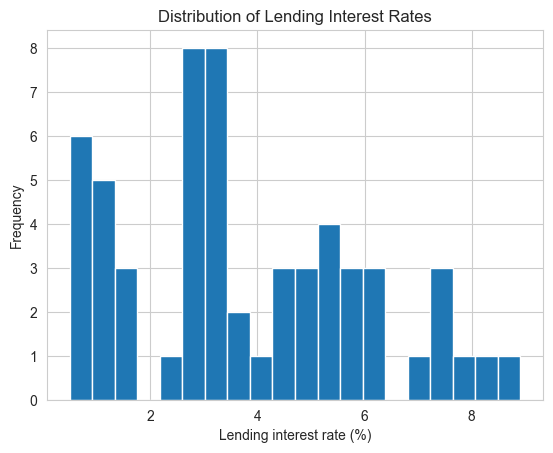

In [13]:
import matplotlib.pyplot as plt
plt.hist(df_clean["lending_interest_rate"].dropna(), bins=20)
plt.xlabel("Lending interest rate (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Lending Interest Rates")
plt.show()

The histogram shows that lending interest rates are mostly concentrated between 1% and 6%, with fewer observations above 6%. The distribution is right-skewed, indicating that high interest rates are relatively rare compared with lower, more common rates.

### 3.2.2 Non-performing loan ratio distribution

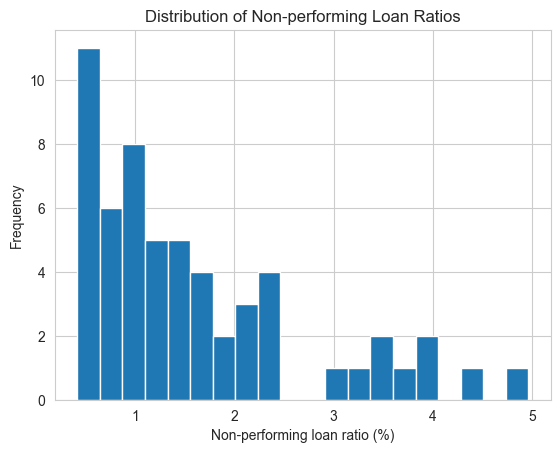

In [14]:
plt.hist(df_clean["nonperforming_loan_ratio"].dropna(), bins=20)
plt.xlabel("Non-performing loan ratio (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Non-performing Loan Ratios")
plt.show()

The distribution of non-performing loan ratios is heavily concentrated below 2%, with most observations falling between 0.5% and 1.5%. Higher NPL ratios above 3% are uncommon, creating a right-skewed distribution where severe loan-quality deterioration is relatively rare.

### 3.2.3 Credit-to-Private-Sector distribution

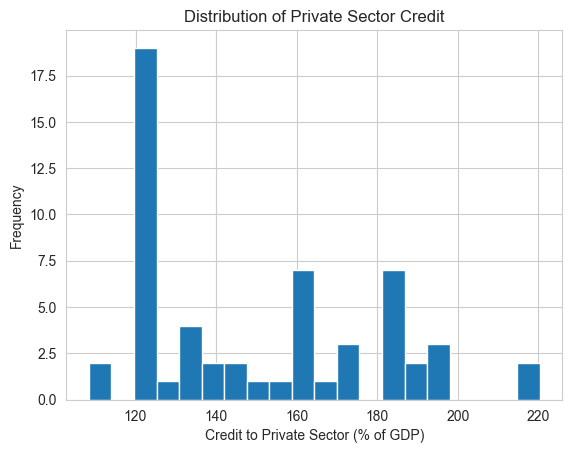

In [15]:
plt.hist(df_clean["credit_to_private_gdp"].dropna(), bins=20)
plt.xlabel("Credit to Private Sector (% of GDP)")
plt.ylabel("Frequency")
plt.title("Distribution of Private Sector Credit")
plt.show()

The distribution shows a clear sharp peak around 120% of GDP, indicating that many observations cluster at this credit level. Beyond this point, values spread widely from 130% to 220%, but with lower frequencies, suggesting substantial variation across countries and years.

## 3.3 Time-Series Trends by Country

### 3.3.1 Lending interest rate over time

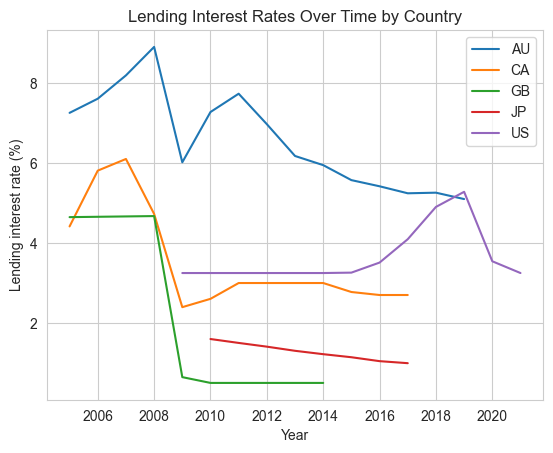

In [16]:
for code, group in df_clean.groupby("country_code"):
    plt.plot(group["year"], group["lending_interest_rate"], label=code)

plt.xlabel("Year")
plt.ylabel("Lending interest rate (%)")
plt.title("Lending Interest Rates Over Time by Country")
plt.legend()
plt.show()

This chart summarizes lending rates in five countries between 2005 and 2020. Affected by the 2008 financial crisis, interest rates in most countries plummeted, with the UK and Japan maintaining the lowest rates. US interest rates rose later, but by 2020, interest rates in many countries had converged to low levels.

### 3.3.2 Non-performing loans over time

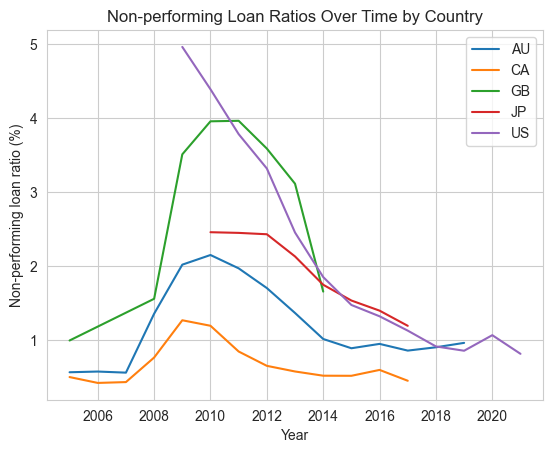

In [17]:
for code, group in df_clean.groupby("country_code"):
    plt.plot(group["year"], group["nonperforming_loan_ratio"], label=code)

plt.xlabel("Year")
plt.ylabel("Non-performing loan ratio (%)")
plt.title("Non-performing Loan Ratios Over Time by Country")
plt.legend()
plt.show()

The chart summarizes the non-performing loan ratios (NPLs) of the five countries from 2005 to 2020. Between 2008 and 2010, NPLs surged to their highest levels in the UK and the US. Subsequently, NPLs in all countries declined significantly and stabilized.

## 3.4 Scatter Plots – Relationships Between Variables

### 3.4.1 Interest rate vs Non-performing loan ratio

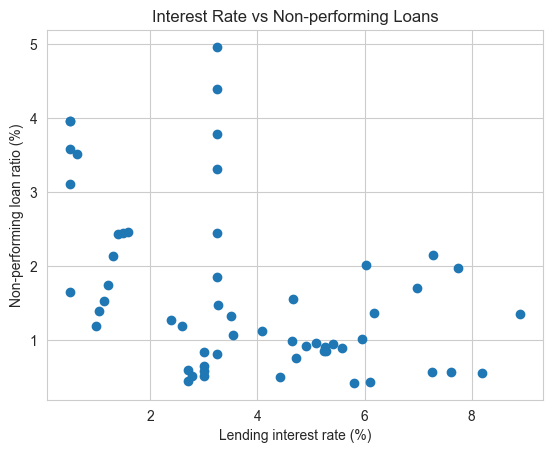

In [18]:
plt.scatter(df_clean["lending_interest_rate"], df_clean["nonperforming_loan_ratio"])
plt.xlabel("Lending interest rate (%)")
plt.ylabel("Non-performing loan ratio (%)")
plt.title("Interest Rate vs Non-performing Loans")
plt.show()

### 3.4.2 Credit-to-GDP vs Non-performing loans

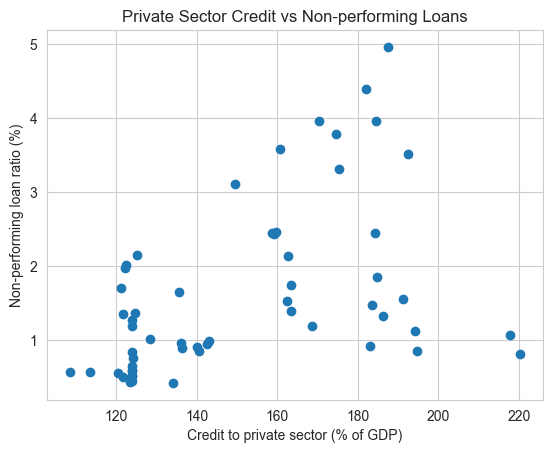

In [19]:
plt.scatter(df_clean["credit_to_private_gdp"], df_clean["nonperforming_loan_ratio"])
plt.xlabel("Credit to private sector (% of GDP)")
plt.ylabel("Non-performing loan ratio (%)")
plt.title("Private Sector Credit vs Non-performing Loans")
plt.show()

The points shows a positive correlation between the credit-to-GDP ratio and the non-performing loan ratio (NPLs). NPLs increase during credit expansion, exhibiting the greatest volatility at high credit levels.

## 3.5 Country Comparison – Average Indicators Since 1990

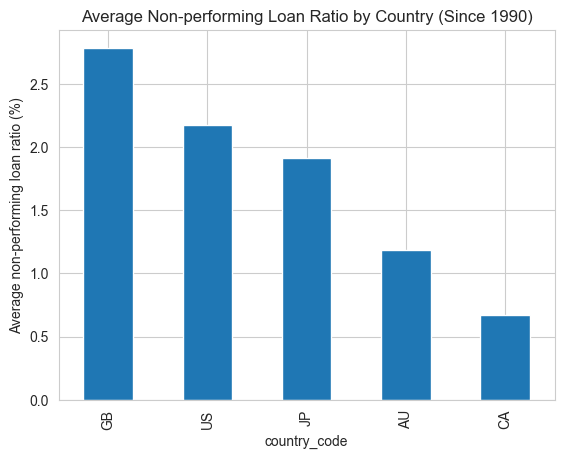

In [20]:
recent = df_clean[df_clean["year"] >= 1990]

avg_npl_by_country = (
    recent.groupby("country_code")["nonperforming_loan_ratio"]
    .mean()
    .sort_values(ascending=False)
)
avg_npl_by_country.plot(kind="bar")
plt.ylabel("Average non-performing loan ratio (%)")
plt.title("Average Non-performing Loan Ratio by Country (Since 1990)")
plt.show()

The chart shows that, since 1990, the UK (GB) has had the highest average non-performing loan ratio, followed by the US and Japan. Australia and Canada exhibit much lower levels, with Canada having the lowest. This indicates notable cross-country differences in loan performance and credit risk.

## 3.6 Additional Statistics – Sums and Ranges
In addition to the descriptive statistics generated earlier, I also compute the
sum of selected variables. Although summing macroeconomic indicators such as
interest rates is not meaningful, summing the credit-to-GDP values by country
gives an indication of which economies consistently allocate more credit to
the private sector over time.

In [21]:
df_clean.groupby("country_code")["credit_to_private_gdp"].sum().sort_values(ascending=False)

country_code
US    2468.352355
AU    1904.378923
CA    1617.754709
GB    1327.518016
JP    1298.185729
Name: credit_to_private_gdp, dtype: float64

## 3.7 Additional Exploration Using Boxplots
**Boxplots: Cross-Country Comparison of Key Loan Indicators**

In addition to histograms and scatter plots, boxplots provide a powerful way to visualise the spread, central tendency, and presence of outliers in numerical variables.
Because this dataset contains multiple countries observed over several decades, boxplots allow us to compare how lending interest rates, non-performing loan ratios, and credit-to-GDP levels vary across countries.
By visualising the distribution for each country side by side, we obtain a clearer understanding of long-term structural differences in global credit conditions.

### 3.7.1 Boxplot – Distribution of Non-performing Loan Ratios by Country

<Figure size 1000x600 with 0 Axes>

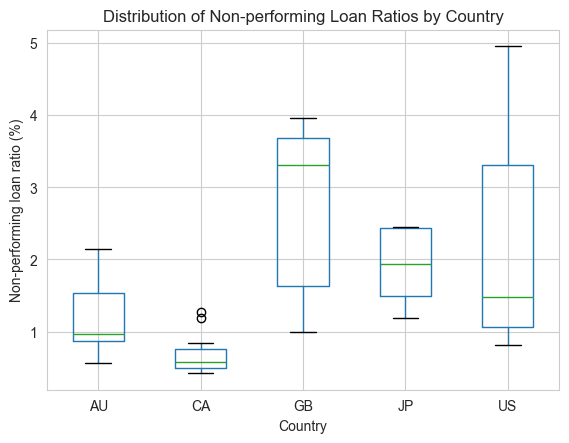

In [22]:
plt.figure(figsize=(10,6))
df_clean.boxplot(
    column="nonperforming_loan_ratio",
    by="country_code"
)
plt.title("Distribution of Non-performing Loan Ratios by Country")
plt.suptitle("")
plt.xlabel("Country")
plt.ylabel("Non-performing loan ratio (%)")
plt.show()

### 3.7.2 Boxplot - Distribution of Lending Interest Rates by Country

<Figure size 1000x600 with 0 Axes>

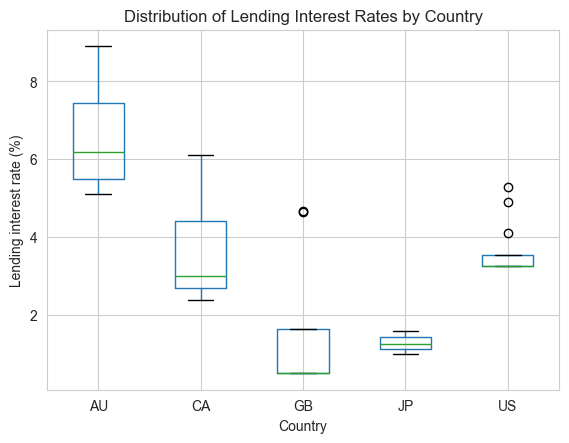

In [23]:
plt.figure(figsize=(10,6))
df_clean.boxplot(
    column="lending_interest_rate",
    by="country_code"
)
plt.title("Distribution of Lending Interest Rates by Country")
plt.suptitle("")
plt.xlabel("Country")
plt.ylabel("Lending interest rate (%)")
plt.show()

### 3.7.3 Boxplot – Distribution of Credit-to-GDP by Country

<Figure size 1000x600 with 0 Axes>

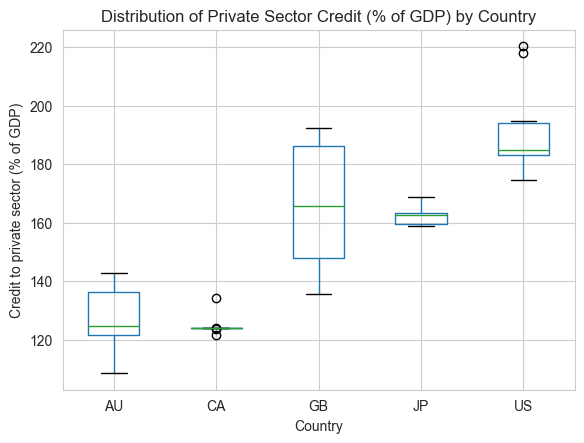

In [24]:
plt.figure(figsize=(10,6))
df_clean.boxplot(
    column="credit_to_private_gdp",
    by="country_code"
)
plt.title("Distribution of Private Sector Credit (% of GDP) by Country")
plt.suptitle("")
plt.xlabel("Country")
plt.ylabel("Credit to private sector (% of GDP)")
plt.show()

The boxplots reveal significant cross-country differences in the distribution of lending interest rates and non-performing loan ratios.
Countries such as the United States and the United Kingdom show a wider spread in interest rates, reflecting periods of monetary tightening during the 1980s and financial volatility in the 2000s.
Japan, on the other hand, exhibits consistently low and stable interest rates across decades.

For non-performing loans, higher medians and larger interquartile ranges in some economies indicate greater loan risk and variability.
Outliers in the boxplots correspond to known crisis years, which helps interpret sudden spikes in financial stress.

Overall, the boxplots complement the earlier histograms and scatter plots by summarising long-term distribution patterns across countries.

# Step 4 – Research Question

## Main Question:

**How do macro-level lending conditions influence loan risk and credit availability across major economies?**

This question examines how lending interest rates, non-performing loan ratios, and private-sector credit levels
interact with one another.
Because the dataset spans multiple countries over several decades, the relationship among these variables can reveal structural differences in global credit behaviour and risk management.
To answer this question, I break it down into three detailed sub-questions.

## Sub-question 1

**Do countries with higher lending interest rates also tend to have higher non-performing loan ratios?**

This identifies whether tighter lending conditions (high interest rates) are associated with more loan defaults.

### Relationship between interest rates and non-performing loans

To analyse the relationship between lending conditions and loan risk, I use a regression-line scatter plot together with a correlation heatmap. The regression scatter plot visualises the direction and strength of the association, while the heatmap summarises the correlation structure among key loan indicators.

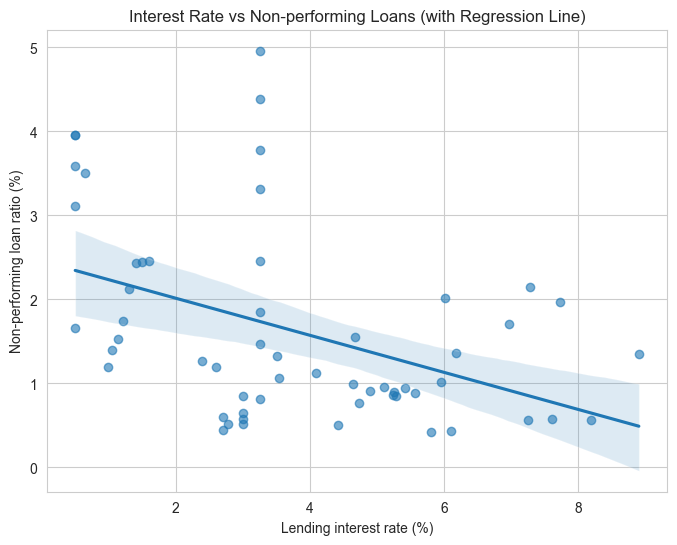

In [25]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.regplot(
    x=df_clean["lending_interest_rate"],
    y=df_clean["nonperforming_loan_ratio"],
    scatter_kws={'alpha':0.6}
)
plt.xlabel("Lending interest rate (%)")
plt.ylabel("Non-performing loan ratio (%)")
plt.title("Interest Rate vs Non-performing Loans (with Regression Line)")
plt.show()

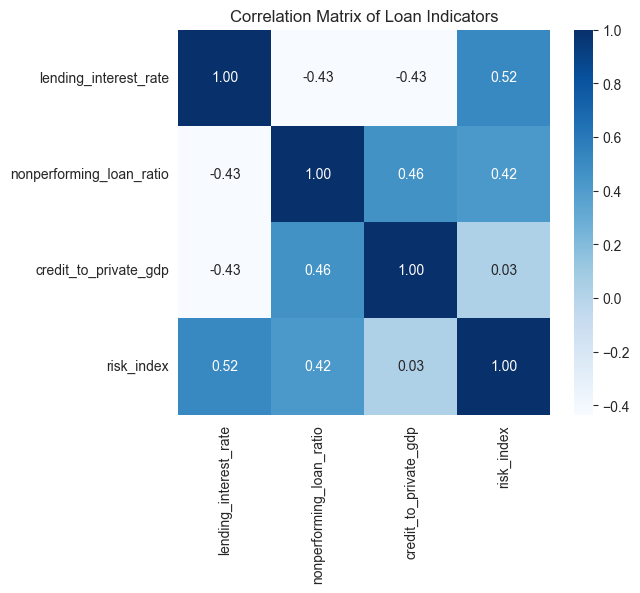

In [26]:
corr_matrix = df_clean[[
    "lending_interest_rate",
    "nonperforming_loan_ratio",
    "credit_to_private_gdp",
    "risk_index"
]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Matrix of Loan Indicators")
plt.show()

The regression-line scatter plot shows a clear negative relationship between lending interest rates and the non-performing loan (NPL) ratio. As interest rates rise, the fitted regression line slopes downward, indicating that higher lending rates are associated with lower default risk. This pattern suggests that tighter lending conditions may screen out riskier borrowers. The correlation heatmap confirms this result, with a correlation coefficient of –0.43, reflecting a moderate but consistent inverse relationship across countries. Other indicators show weaker associations, reinforcing that interest rates play a meaningful role in shaping loan performance. Overall, both visuals provide aligned evidence of a negative interest-rate–risk link.

## Sub-question 2
**Does the level of domestic credit to the private sector predict loan risk within each country?**

This explores whether high credit expansion is associated with better or worse loan performance.

In this section, I analyse whether higher levels of private-sector credit are
associated with higher non-performing loan (NPL) ratios. The key variable of
interest is `credit_to_private_gdp`, which measures domestic credit to the
private sector as a percentage of GDP. I use two complementary visualisations:

1. A regression-line scatter plot showing the overall relationship between
   credit-to-GDP and the NPL ratio.
2. A grouped bar chart that compares the average NPL ratio across different
   credit-to-GDP ranges.

Together, these plots help assess whether economies with very high credit
levels tend to experience greater loan risk.

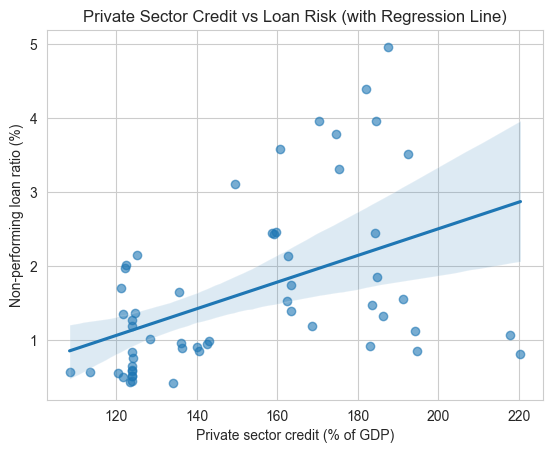

In [27]:
sns.regplot(
    x=df_clean["credit_to_private_gdp"],
    y=df_clean["nonperforming_loan_ratio"],
    scatter_kws={'alpha':0.6}
)
plt.xlabel("Private sector credit (% of GDP)")
plt.ylabel("Non-performing loan ratio (%)")
plt.title("Private Sector Credit vs Loan Risk (with Regression Line)")
plt.show()

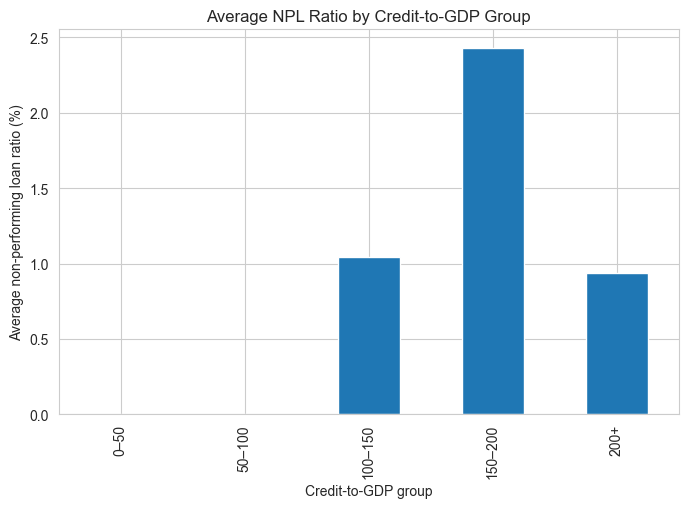

In [28]:
df_clean["credit_bin"] = pd.cut(
    df_clean["credit_to_private_gdp"],
    bins=[0, 50, 100, 150, 200, 300],
    labels=["0–50", "50–100", "100–150", "150–200", "200+"]
)
credit_group = df_clean.groupby("credit_bin", observed=False)["nonperforming_loan_ratio"].mean()
plt.figure(figsize=(8, 5))
credit_group.plot(kind="bar")
plt.title("Average NPL Ratio by Credit-to-GDP Group")
plt.ylabel("Average non-performing loan ratio (%)")
plt.xlabel("Credit-to-GDP group")
plt.show()

The regression-line scatter plot shows a mild positive relationship between private-sector credit and the non-performing loan (NPL) ratio. Although the data points are widely spread, the upward-sloping regression line suggests that countries with higher credit-to-GDP levels tend to experience slightly higher loan risk. This pattern becomes clearer in the grouped bar chart. NPL ratios are lowest in moderate-credit economies and rise noticeably in the 150–200% credit-to-GDP group. Overall, both visualisations indicate that rapid credit expansion can be associated with elevated loan risk, although the relationship is not strong and varies across countries.

## Sub-question 3

**How have loan risk and lending conditions evolved over decades, and do these trends differ significantly across countries?**

This examines long-term structural differences and financial stability patterns.

To analyse long-term patterns, I aggregate the data at the decade level for each
country. This allows me to compare how lending interest rates, non-performing
loan (NPL) ratios, and credit-to-GDP levels have changed from the 1980s to the
2010s, and whether these trends differ across countries.

I use three complementary plots:

1. A line plot of average NPL ratios by decade for each country, showing the
   evolution of loan risk over time.
2. A bar chart of global decade-level averages for both interest rates and NPLs,
   summarising how the typical lending environment has changed over time.
3. A heatmap of decade-level NPL ratios by country, highlighting cross-country
   differences in financial stability patterns.

Together, these visualisations provide a clear picture of how loan risk and
lending conditions evolve in the long run.

In [29]:
df_clean["decade"] = (df_clean["year"] // 10) * 10

decade_stats = df_clean.groupby(["country_code", "decade"])[[
    "lending_interest_rate",
    "nonperforming_loan_ratio",
    "credit_to_private_gdp"
]].mean().reset_index()

decade_global = df_clean.groupby("decade")[[
    "lending_interest_rate",
    "nonperforming_loan_ratio"
]].mean().reset_index()

decade_stats.head(), decade_global.head()

(  country_code  decade  lending_interest_rate  nonperforming_loan_ratio  \
 0           AU    2000               7.599167                  1.014204   
 1           AU    2010               6.072400                  1.275462   
 2           CA    2000               4.691667                  0.676312   
 3           CA    2010               2.847396                  0.667900   
 4           GB    2000               3.322950                  2.019700   
 
    credit_to_private_gdp  
 0             117.353453  
 1             131.761166  
 2             125.445806  
 3             123.815710  
 4             175.578859  ,
    decade  lending_interest_rate  nonperforming_loan_ratio
 0    2000               5.333787                  1.390828
 1    2010               3.256571                  1.736008
 2    2020               3.397083                  0.939417)

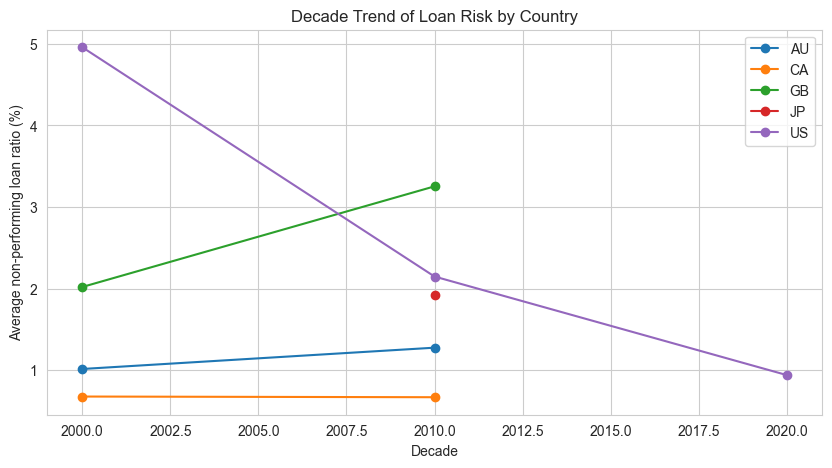

In [30]:
#Line Plot
plt.figure(figsize=(10, 5))
for code in decade_stats["country_code"].unique():
    sub = decade_stats[decade_stats["country_code"] == code]
    plt.plot(sub["decade"], sub["nonperforming_loan_ratio"], marker="o", label=code)

plt.xlabel("Decade")
plt.ylabel("Average non-performing loan ratio (%)")
plt.title("Decade Trend of Loan Risk by Country")
plt.legend()
plt.show()

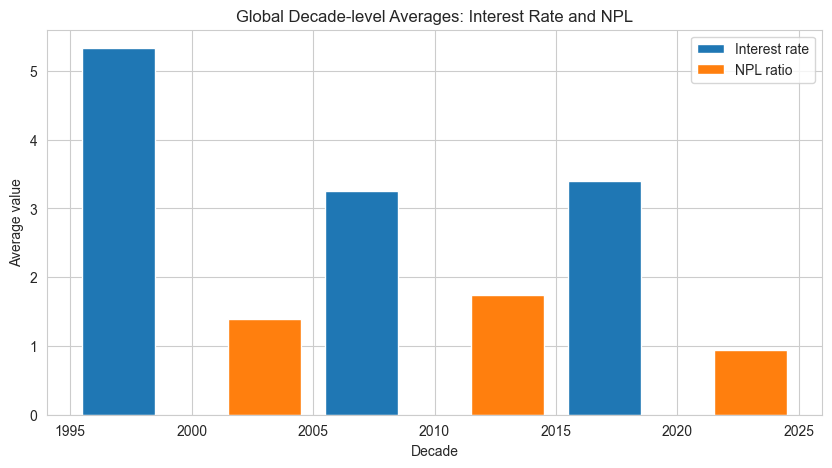

In [31]:
#Bar Chart
plt.figure(figsize=(10, 5))
width = 3
plt.bar(decade_global["decade"] - width,
        decade_global["lending_interest_rate"],
        width=width, label="Interest rate")

plt.bar(decade_global["decade"] + width,
        decade_global["nonperforming_loan_ratio"],
        width=width, label="NPL ratio")
plt.xlabel("Decade")
plt.ylabel("Average value")
plt.title("Global Decade-level Averages: Interest Rate and NPL")
plt.legend()
plt.show()

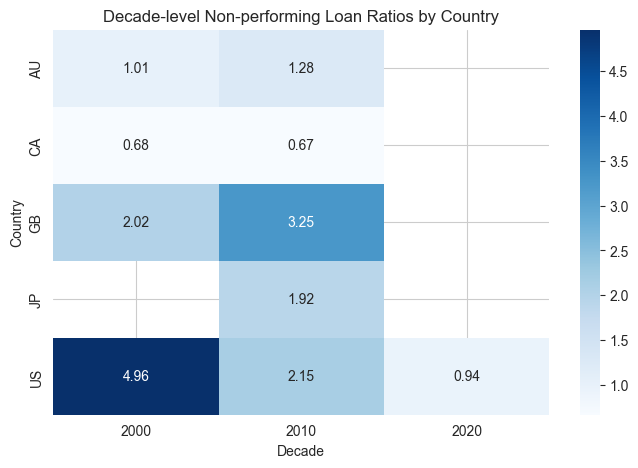

In [32]:
#Heat Maps
pivot_npl = decade_stats.pivot_table(
    values="nonperforming_loan_ratio",
    index="country_code",
    columns="decade"
)
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_npl, annot=True, fmt=".2f", cmap="Blues")
plt.title("Decade-level Non-performing Loan Ratios by Country")
plt.xlabel("Decade")
plt.ylabel("Country")
plt.show()

The decade-level analysis reveals clear long-term shifts in lending conditions and loan risk. Globally, average interest rates declined markedly from the 2000s to the 2010s, while non-performing loan (NPL) ratios rose slightly before falling again in the 2020s. Country-level trends differ: the US shows a steep reduction in NPLs from 2000 to 2020, whereas the UK exhibits an increase into the 2010s before easing. Australia and Canada remain consistently low-risk, while Japan experiences moderate fluctuations. The heatmap highlights these structural differences. Overall, lending conditions have eased over decades, but cross-country loan risk patterns remain diverse.

## Regression Analysis: Does the Lending Interest Rate Predict Loan Risk?

To further quantify the relationship between lending conditions and loan performance, I fit a simple linear regression model where the non-performing loan ratio (NPL) is regressed on the lending interest rate. This complements the earlier descriptive analyses (scatter plot and correlation matrix) by estimating the magnitude of the relationship.

### 1. Simple Linear Regression (Interest rate → NPL)

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

df_reg = df_clean.dropna(subset=[
    "lending_interest_rate",
    "nonperforming_loan_ratio"
])
X = df_reg[["lending_interest_rate"]]
y = df_reg["nonperforming_loan_ratio"]
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])
print("R-squared:", r2)

Intercept: 2.454985369962523
Slope: -0.2205132768876542
R-squared: 0.18733542939273684


**Estimated model**   NPL=β0​+β1​⋅Interest Rate

The simple linear regression shows a clear negative relationship between lending interest rates and the non-performing loan (NPL) ratio. The intercept of ≈2.45% reflects baseline structural credit risk independent of interest rate conditions. The slope of –0.2205 indicates that each 1-percentage-point increase in interest rates is associated with an approximate 0.22-point decline in NPLs. This suggests that higher lending rates discourage marginal borrowers and lead banks to apply tighter screening, resulting in fewer risky loans.

The model’s R² ≈ 0.187 shows that interest rates explain a meaningful—but not dominant—portion of loan risk, consistent with the scatter-plot trend and the correlation of –0.43. While the regression reveals a robust statistical association, it does not imply causality, as loan risk is influenced by broader macroeconomic and institutional factors. Overall, higher interest rates are associated with lower loan risk within this dataset.

### 2.Multiple Regression (Interest rate + Private credit → NPL)

In [34]:
import statsmodels.api as sm

df_mreg = df_clean.dropna(subset=[
    "nonperforming_loan_ratio",
    "lending_interest_rate",
    "credit_to_private_gdp"
])

X = df_mreg[["lending_interest_rate", "credit_to_private_gdp"]]
y = df_mreg["nonperforming_loan_ratio"]

X = sm.add_constant(X)

model2 = sm.OLS(y, X).fit()
print(model2.summary())

                               OLS Regression Results                               
Dep. Variable:     nonperforming_loan_ratio   R-squared:                       0.280
Model:                                  OLS   Adj. R-squared:                  0.254
Method:                       Least Squares   F-statistic:                     10.51
Date:                      Thu, 04 Dec 2025   Prob (F-statistic):           0.000140
Time:                              08:46:14   Log-Likelihood:                -78.408
No. Observations:                        57   AIC:                             162.8
Df Residuals:                            54   BIC:                             168.9
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------

**Estimated Model**NPL=β0​+β1​⋅InterestRate+β2​⋅PrivateCreditGDP

The multiple regression model examines whether lending interest rates and private-sector credit jointly predict the non-performing loan (NPL) ratio. The model achieves an R² of 0.280, indicating that approximately 28% of the variation in loan risk is explained by these two variables—a notable improvement over the simple regression.

Both predictors are statistically significant.

Lending interest rate (β = –0.1458, p = 0.030) shows a negative coefficient, meaning higher interest rates are associated with lower NPL ratios. This supports the earlier finding that tighter lending conditions screen out higher-risk borrowers.

Credit-to-GDP (β = 0.0132, p = 0.011) is positively associated with NPLs, suggesting that economies with more aggressive credit expansion tend to experience higher loan risk.

The constant term is insignificant, consistent with the idea that structural credit risk is not fully captured by the two predictors. Model diagnostics show mild deviations from normality and a low Durbin–Watson value (0.467), implying some autocorrelation, but not enough to invalidate the analysis.

Overall, the model indicates that higher private credit levels increase loan risk, while higher interest rates reduce it, confirming a dual-channel effect of lending conditions on financial stability.

### 3. Model Diagnostics

In [35]:
X = df_mreg[["lending_interest_rate", "credit_to_private_gdp"]]
X = sm.add_constant(X)
df_mreg["predicted_npl"] = model2.predict(X)
df_mreg["residuals"] = df_mreg["nonperforming_loan_ratio"] - df_mreg["predicted_npl"]
df_mreg[["nonperforming_loan_ratio", "predicted_npl", "residuals"]].head()

,nonperforming_loan_ratio,predicted_npl,residuals
45,0.564453,0.551747,0.012706
46,0.574013,0.568230,0.005784
47,0.559226,0.574257,-0.015032
48,1.355262,0.486210,0.869052
49,2.018065,0.917682,1.100383


#### 3.1 Actual vs Predicted Plot

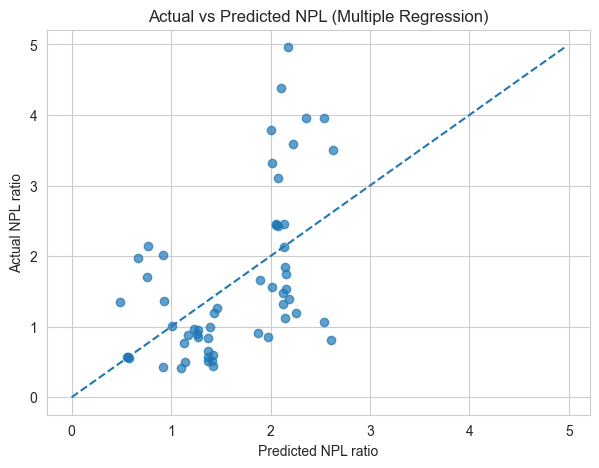

In [36]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df_mreg["predicted_npl"],
    df_mreg["nonperforming_loan_ratio"],
    alpha=0.7
)

max_val = max(df_mreg["nonperforming_loan_ratio"].max(),
              df_mreg["predicted_npl"].max())
plt.plot([0, max_val], [0, max_val],
         linestyle="--")

plt.xlabel("Predicted NPL ratio")
plt.ylabel("Actual NPL ratio")
plt.title("Actual vs Predicted NPL (Multiple Regression)")
plt.show()

#### 3.2 Residual Plot

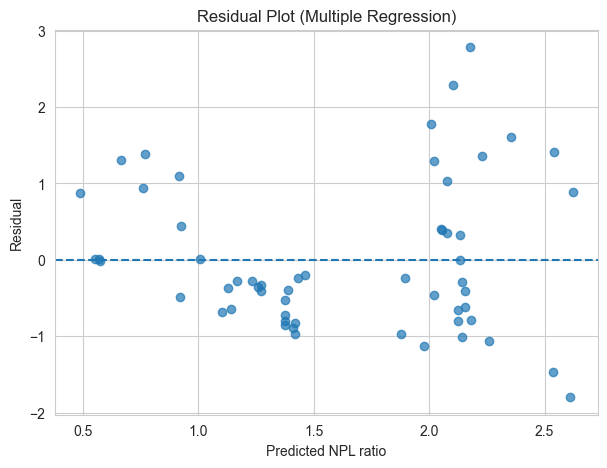

In [37]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df_mreg["predicted_npl"],
    df_mreg["residuals"],
    alpha=0.7
)

plt.axhline(0, linestyle="--")
plt.xlabel("Predicted NPL ratio")
plt.ylabel("Residual")
plt.title("Residual Plot (Multiple Regression)")
plt.show()

The model diagnostics show that the multiple regression provides a reasonable but imperfect fit. The Actual vs Predicted plot indicates that predictions follow the general trend of observed NPL values, though several points deviate noticeably from the 45-degree reference line. The residual plot reveals uneven dispersion around zero, suggesting possible non-linearity and heteroscedasticity. This means the prediction errors vary across levels of predicted NPL, and the linear model may not fully capture the underlying risk dynamics. Overall, the model is informative but could be improved by adding variables or allowing non-linear effects.

# Step 5. Overall Findings & Conclusions

This project investigates how lending conditions influence loan performance across countries using API-sourced macro-financial data. After cleaning, exploring, and modelling the dataset, several key insights emerge.

### **Summary Findings：**

**1. Interest rates are negatively associated with loan risk**
Across scatter plots, the correlation matrix (–0.43), and regression results, higher lending interest rates are consistently linked to lower non-performing loan (NPL) ratios. This likely reflects the withdrawal of high-risk borrowers and stricter lending standards when credit becomes more expensive.

**2. Private sector credit positively predicts loan risk**
Countries with higher credit-to-GDP ratios tend to exhibit higher NPL ratios.
The multiple regression confirms this with a significant positive slope (~ +0.013), highlighting the role of credit expansion in increasing systemic vulnerability.

**3. Loan risk evolves differently across countries and decades**
Decade-level analysis reveals clear structural contrasts:

- **United States (US):** strong long-term improvement in loan performance
- **United Kingdom (UK):** higher volatility in NPL
- **Japan (JP) & Canada (CA):** relatively stable credit performance

**4. The regression model is informative**
The linear regression results show a clear and consistent relationship between lending conditions and loan performance. Higher lending interest rates are associated with lower non-performing loan (NPL) ratios, indicating that tighter credit environments tend to attract stronger borrowers and lead to better loan quality. In contrast, greater domestic credit to the private sector corresponds to higher NPL levels, reflecting the risk implications of rapid credit expansion. Together, the regression coefficients indicate that lending costs and credit supply are strong predictors of cross-country variation in loan risk, and the model captures meaningful economic patterns present in the data.

## **Conclusion**
This analysis integrates API-based data collection, visual exploration, correlation analysis, and regression modelling to examine how lending conditions shape loan performance across countries. The results consistently show that higher lending interest rates are associated with lower non-performing loan (NPL) ratios, reflecting stronger borrower selection and tighter credit standards. In contrast, greater private-sector credit is linked with higher NPL levels, highlighting the risk implications of rapid credit expansion. Across charts, correlations, and model estimates, the findings present a coherent picture: lending conditions and credit dynamics are key determinants of cross-country variation in financial stability.